# Covertype - Exploratory Data Analysis

Perform an exploratory data analysis over the dataset `Covertype` in order to uncover patterns & distribution for guiding subsequent modeling steps.

# Setup Notebook

## Imports

In [2]:
# Import Standard Libraries
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.gridspec import GridSpec
from colorama import Style, Fore
from dotenv import load_dotenv
from pathlib import Path
from dynaconf import Dynaconf


## Setup Plot Characteristics

In [16]:
# Define Seaborn theme parameters
theme_parameters = {
    "axes.spines.right": False,
    "axes.spines.top": False,
    "grid.alpha": 0.3,
    "figure.figsize": (16, 6),
    "font.family": "Andale Mono",
    "axes.titlesize": 24,
    "figure.facecolor": "#E5E8E8",
    "axes.facecolor": "#E5E8E8",
}

# Set the theme
sns.set_theme(style="whitegrid", palette=sns.color_palette("deep"), rc=theme_parameters)

# Define Colors
black = Style.BRIGHT + Fore.BLACK
magenta = Style.BRIGHT + Fore.MAGENTA
red = Style.BRIGHT + Fore.RED
blue = Style.BRIGHT + Fore.BLUE
reset_colors = Style.RESET_ALL

## Define Configurations

In [4]:
# Read .env file
load_dotenv()

# Setup root path
root_path = Path(os.getenv("DRUIDIC_GROVE_AI_ROOT_PATH"))

print(f"🛤️ Root path: {root_path}")

# Read configurations
config = Dynaconf(
    settings_files=[root_path / "configurations" / "covertype" / "eda_config.toml"]
)

# Read configurations
covertype_data_path = config["data_sources"]["covertype_data_path"]
covertype_columns = config["data_sources"]["covertype_columns"]
features = config["features_to_analyse"]["features"]

🛤️ Root path: /Users/simone.porreca/Projects/DruidicGroveAI


## Read Data

In [5]:
# Read data files
covertype_data = pd.read_csv(root_path / covertype_data_path)
covertype_data.columns = covertype_columns
covertype_data = covertype_data[features]

# Exploratory Data Analysis

## General

In [6]:
covertype_data.info()
covertype_data.sample(5)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 581011 entries, 0 to 581010
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype
---  ------      --------------   -----
 0   Elevation   581011 non-null  int64
 1   Aspect      581011 non-null  int64
 2   Slope       581011 non-null  int64
 3   Cover_Type  581011 non-null  int64
dtypes: int64(4)
memory usage: 17.7 MB


,Elevation,Aspect,Slope,Cover_Type
463845,3182,89,12,2
185626,3083,105,7,2
506677,3280,6,6,1
80488,2634,141,22,2
270953,3039,40,20,2


In [7]:
print(f"{blue}Data Shapes:{blue}\n- All Data -> {red}{covertype_data.shape}\n")
print(
    f"{blue}Data Columns with Null Values:"
    f"{blue}\n- All Data -> {red}{covertype_data.isnull().any().sum()}\n"
)

Data Shapes:
- All Data -> (581011, 4)

Data Columns with Null Values:
- All Data -> 0



## Null Values

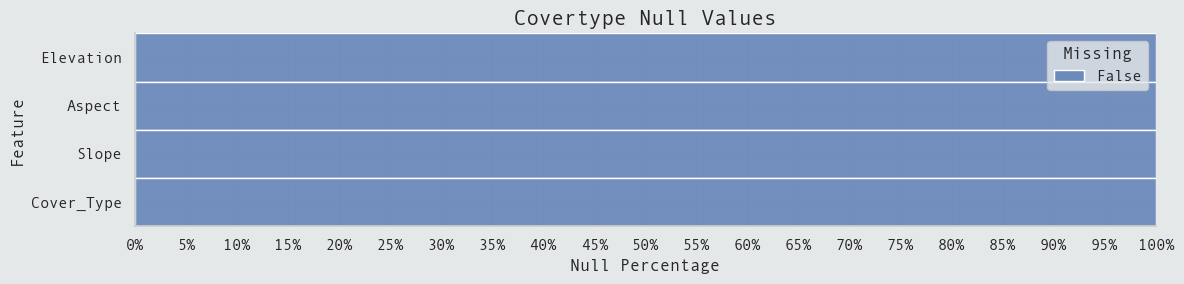

In [8]:
figure = plt.figure(tight_layout=True, figsize=(12, 3))
grid_spec = GridSpec(1, 1)
ax = figure.add_subplot(grid_spec[0, 0])

sns.histplot(
    data=covertype_data.isna().melt(var_name="Feature", value_name="Missing"),
    y="Feature",
    hue="Missing",
    multiple="fill",
    ax=ax,
)

# Refactor x label as missing percentage
ax.xaxis.set_major_locator(ticker.LinearLocator(21))
ax.xaxis.set_major_formatter("{:.0%}".format)

# Set title and label
ax.set_title("Covertype Null Values", fontsize=15)
ax.set_xlabel("Null Percentage")

plt.show()

## Numerical Features Analysis

In [9]:
# Define raw numerical features
raw_numerical_features = ["Elevation", "Aspect", "Slope"]

### General

In [10]:
# Define raw numerical features
raw_numerical_features = ["Elevation", "Aspect", "Slope"]

# Retrieve statistical information
covertype_data[raw_numerical_features].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
Elevation,581011.0,2959.365926,279.984569,1859.0,2809.0,2996.0,3163.0,3858.0
Aspect,581011.0,155.656988,111.913733,0.0,58.0,127.0,260.0,360.0
Slope,581011.0,14.103723,7.488234,0.0,9.0,13.0,18.0,66.0


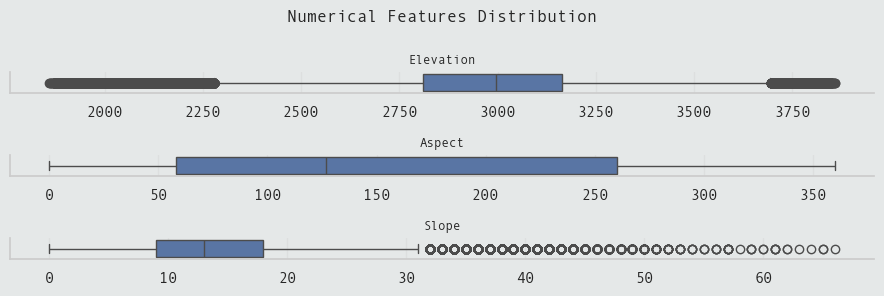

In [11]:
figure, ax = plt.subplots(3, 1, figsize=(9, 3))
ax = ax.flatten()

for index, column_name in enumerate(raw_numerical_features):
    # Plot data
    sns.boxplot(data=covertype_data, x=column_name, ax=ax[index])

    # Set subplot titles
    ax[index].set_title(
        column_name,
        fontweight="bold",
        fontsize=9,
    )

    # Remove labels
    ax[index].set_xlabel("")
    ax[index].set_ylabel("")

# Set figure Title
figure.suptitle("Numerical Features Distribution", fontweight="bold", fontsize=12)
plt.tight_layout()

### Distribution by Cover Type

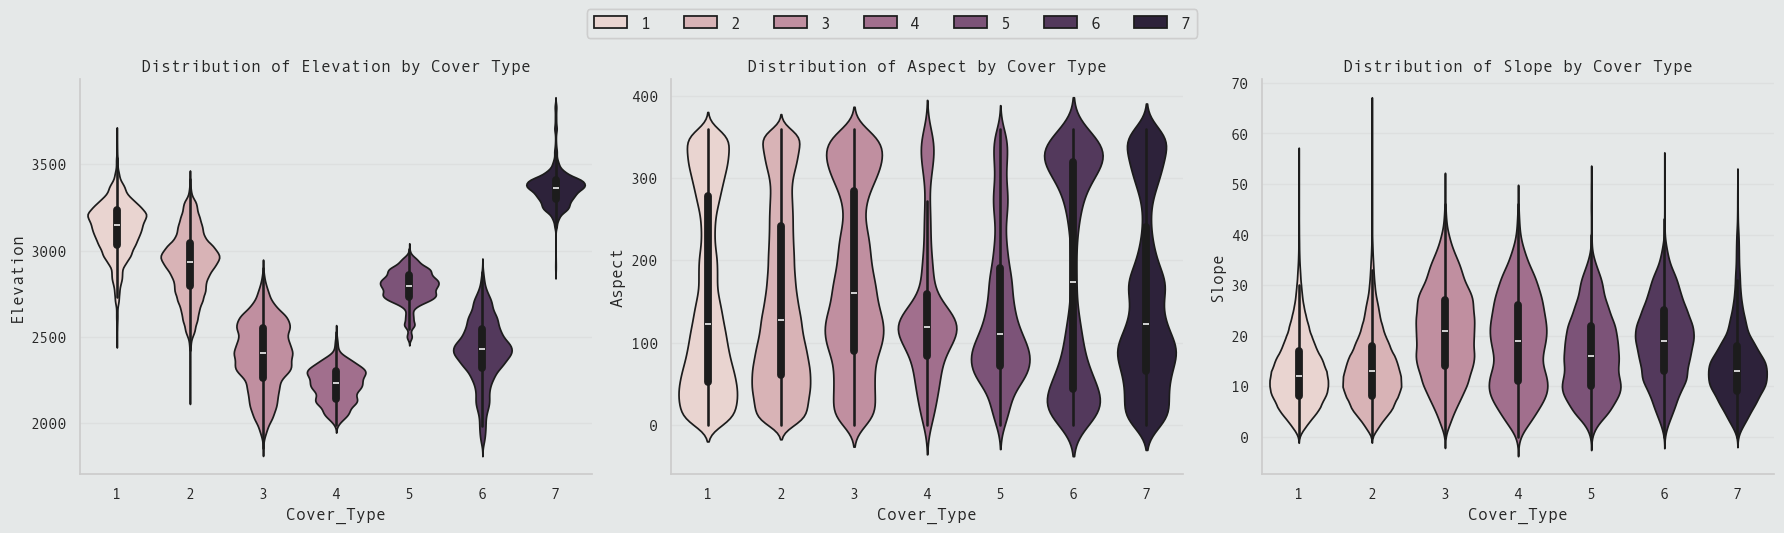

In [12]:
figure, ax = plt.subplots(1, 3, figsize=(18, 5))

for index, column_name in enumerate(raw_numerical_features):
    # Plot
    sns.violinplot(ax=ax[index], x='Cover_Type', y=column_name, data=covertype_data, hue='Cover_Type')

    # Title
    ax[index].set_title(
        f'Distribution of {column_name} by Cover Type',
        fontweight="bold",
        fontsize=12)

    # Legend information
    handles = ax[index].get_legend_handles_labels()[0]
    labels = ax[index].get_legend_handles_labels()[1]
    ax[index].legend().remove()

    figure.legend(handles,
              labels,
              loc='upper center',
              bbox_to_anchor=(0.5, 1.08),
              fontsize=12,
              ncol=covertype_data['Cover_Type'].nunique() + 1)

plt.tight_layout()

### Aspect Distribution

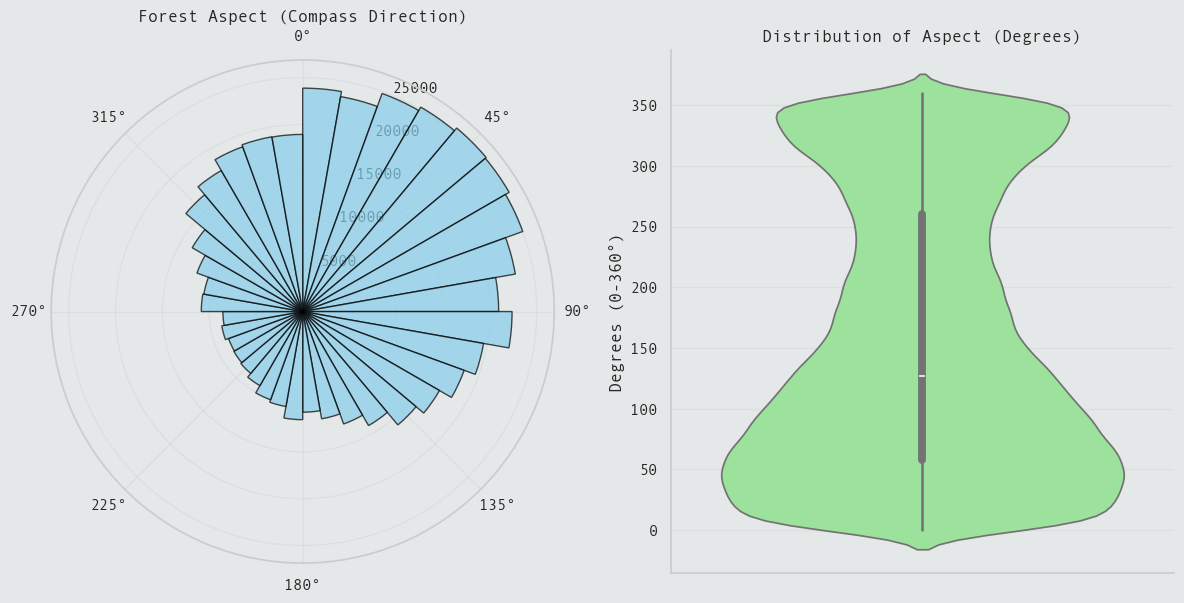

In [35]:
# Set up the figure with two distinct types of axes
fig = plt.figure(figsize=(12, 6))

# Left plot: Polar Projection
ax1 = fig.add_subplot(1, 2, 1, projection='polar')

# Convert degrees to radians
aspect_radians = np.radians(covertype_data['Aspect'])

# Create polar histogram
n, bins, patches = ax1.hist(aspect_radians, bins=36, color='skyblue',
                            edgecolor='black', alpha=0.7)

# Orientation: North at the top, clockwise direction
ax1.set_theta_zero_location('N')
ax1.set_theta_direction(-1)
ax1.set_title("Forest Aspect (Compass Direction)", fontsize=12)

# Right plot: Standard Violin Plot
ax2 = fig.add_subplot(1, 2, 2)
sns.violinplot(y=covertype_data['Aspect'], ax=ax2, color='lightgreen')
ax2.set_title("Distribution of Aspect (Degrees)", fontsize=12)
ax2.set_ylabel("Degrees (0-360°)")

plt.tight_layout()
plt.show()